# Visualizing multi-dataset multi-algorithm results with Critical Difference Diagram

---

## Introduction

This notebook introduces the Critical Difference Diagram in the context of the Bayesian Bradley-Terry (BBT) model implemented in `bbt-test`. We use posterior model strengths ($\beta$) to obtain a global ranking, then summarize pairwise posterior comparisons $P(A_i > A_j \mid D)$ with ROPE-based interpretation to identify groups of models that are practically equivalent. The resulting diagram provides a compact view of which models are better, equivalent, or inconclusive under the chosen BBT interpretation (`weak` or `strong`).

This notebook assumes the reader is familiar with the BBT model and `bbt-test` basics described in the [first notebook](01_simple_bbt_comparison.ipynb).

Steps:
1. [Loading the data](#Loading-the-data)
2. [Fitting the BBT model](#Fitting-the-BBT-model)
3. [Plotting the Critical Difference Diagram](#Plotting-the-Critical-Difference-Diagram)


## Necessary imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from bbttest import BBTTest

## Loading the data

In [2]:
df = pd.read_csv("../datasets/benchmarking_mol.csv")
df.head()

,dataset,AtomPair_count,CDDD,CLAMP,ChemBERTa-10M-MTR,ChemFM-3B,ChemGPT-4.7M,ECFP_count,GEM,GNN-GraphCL-sum,...,chemformer_mask,coati,grover_large,mat_masking_2M,mol2vec,mol_r_tag_1024,molbert,rmat_4M,unimolv1,unimolv2
0,AMES,0.814525,0.835524,0.845998,0.842645,0.819407,0.733519,0.848170,0.712631,0.778957,...,0.801707,0.806224,0.814941,0.817682,0.806354,0.812781,0.853984,0.855419,0.772552,0.805847
1,Bioavailability_Ma,0.712005,0.668773,0.641836,0.744596,0.670436,0.695710,0.691054,0.700532,0.676921,...,0.703193,0.621716,0.883937,0.686731,0.726305,0.587463,0.683572,0.728301,0.660126,0.765381
2,CYP1A2_Veith,0.928864,0.923714,0.950784,0.926163,0.903825,0.867991,0.927867,0.875383,0.897117,...,0.904443,0.897014,0.856961,0.926905,0.913344,0.901323,0.929359,0.930857,0.901899,0.915601
3,CYP2C19_Veith,0.858162,0.872114,0.922305,0.871285,0.853653,0.789982,0.874444,0.770266,0.834949,...,0.839680,0.848842,0.779436,0.874605,0.851539,0.851361,0.885187,0.880757,0.826559,0.863196
4,CYP2C9_Substrate_CarbonMangels,0.596310,0.655182,0.697775,0.692078,0.667933,0.652469,0.627238,0.597396,0.658709,...,0.640532,0.672409,0.572165,0.624525,0.644872,0.604992,0.646636,0.666305,0.594954,0.679327


## Fitting the BBT model

In [3]:
model = BBTTest(
    local_rope_value=0.01,
    hyper_prior="log_normal",
    tie_solver="spread",
    maximize=True,
    scale=1.0,
)

model.fit(
    data=df,
    dataset_col="dataset",
    random_seed=42,
)

Constructing win table:   0%|          | 0/300 [00:00<?, ?it/s]

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [sigma, beta]
>Metropolis: [win1_rep]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## Plotting the Critical Difference Diagram

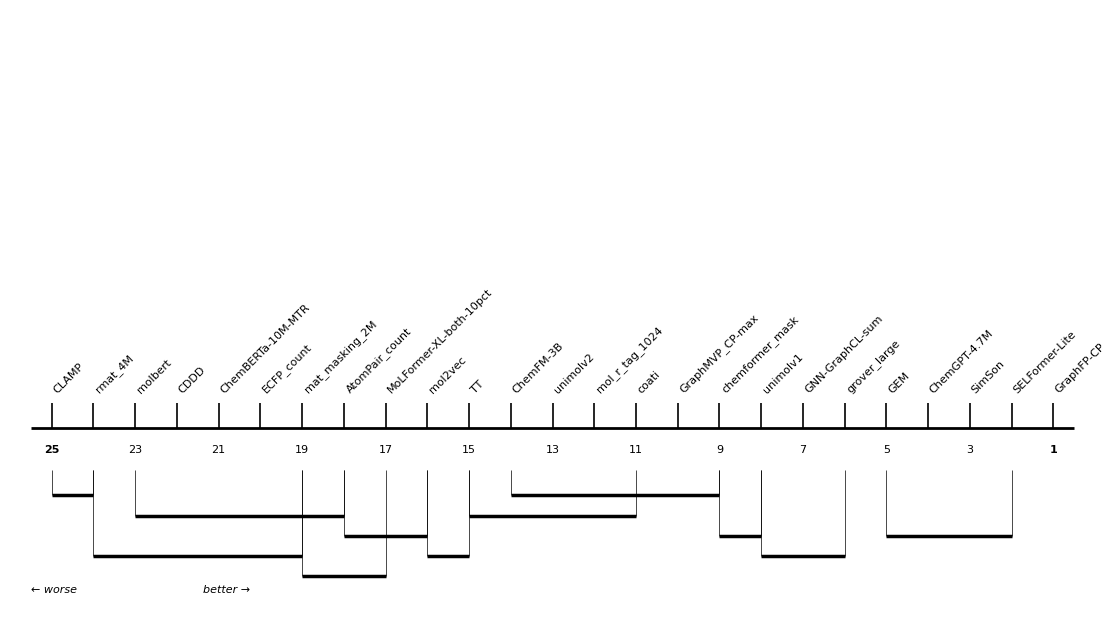

In [4]:
fig, ax = plt.subplots()

model.plot_cdd_diagram(
    rope_value=(0.35, 0.65), interpretation="weak", ax=ax, xlabel_spacing=2
)

fig.set_size_inches(14, 8)